# 04 Alpha Lab

Diagnostic visualizations for 20 candidate alpha signals + top-30 headline templates.

- **Data**: train-only, 1000 sessions. No public/private test leakage.
- **Inputs**: `features/alpha_candidates.parquet`, `features/template_hits.parquet`, `features/template_dictionary.tsv`, targets from `src.data.compute_targets`.
- **Scope**: correlation + Sharpe-of-rule diagnostics only. No modeling.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import KFold

sns.set_theme(style="whitegrid", context="talk")

PLOT_DIR = ROOT / "notebooks" / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
FEAT_DIR = ROOT / "features"

from src.data import compute_targets  # noqa: E402

alphas_df = pd.read_parquet(FEAT_DIR / "alpha_candidates.parquet")
tpl_hits = pd.read_parquet(FEAT_DIR / "template_hits.parquet")
tpl_dict = pd.read_csv(FEAT_DIR / "template_dictionary.tsv", sep="\t")
targets = compute_targets()

# Normalize index/session column across inputs.
if alphas_df.index.name == "session":
    alphas_df = alphas_df.reset_index()
if tpl_hits.index.name == "session":
    tpl_hits = tpl_hits.reset_index()

ALPHA_COLS = [c for c in alphas_df.columns if c != "session"]
TPL_COLS = [c for c in tpl_hits.columns if c != "session"]

df = alphas_df.merge(targets, on="session", how="inner")
df_tpl = tpl_hits.merge(targets, on="session", how="inner")

print("alpha_candidates :", alphas_df.shape, "| alphas:", len(ALPHA_COLS))
print("template_hits    :", tpl_hits.shape, "| templates:", len(TPL_COLS))
print("template_dict    :", tpl_dict.shape)
print("targets          :", targets.shape)
print("merged df        :", df.shape)
print("target mean / std:", f"{targets['target_return'].mean():+.4%}", "/", f"{targets['target_return'].std():.4%}")

alpha_candidates : (1000, 21) | alphas: 20
template_hits    : (1000, 31) | templates: 30
template_dict    : (30, 3)
targets          : (1000, 2)
merged df        : (1000, 22)
target mean / std: +0.3531% / 2.0434%


## Section 1 — Spearman correlation heatmap

Pairwise Spearman ρ across the 20 alphas. Look for clusters: highly correlated alphas are redundant when stacked in a linear position rule. Opposite-sign blocks highlight natural diversifiers.

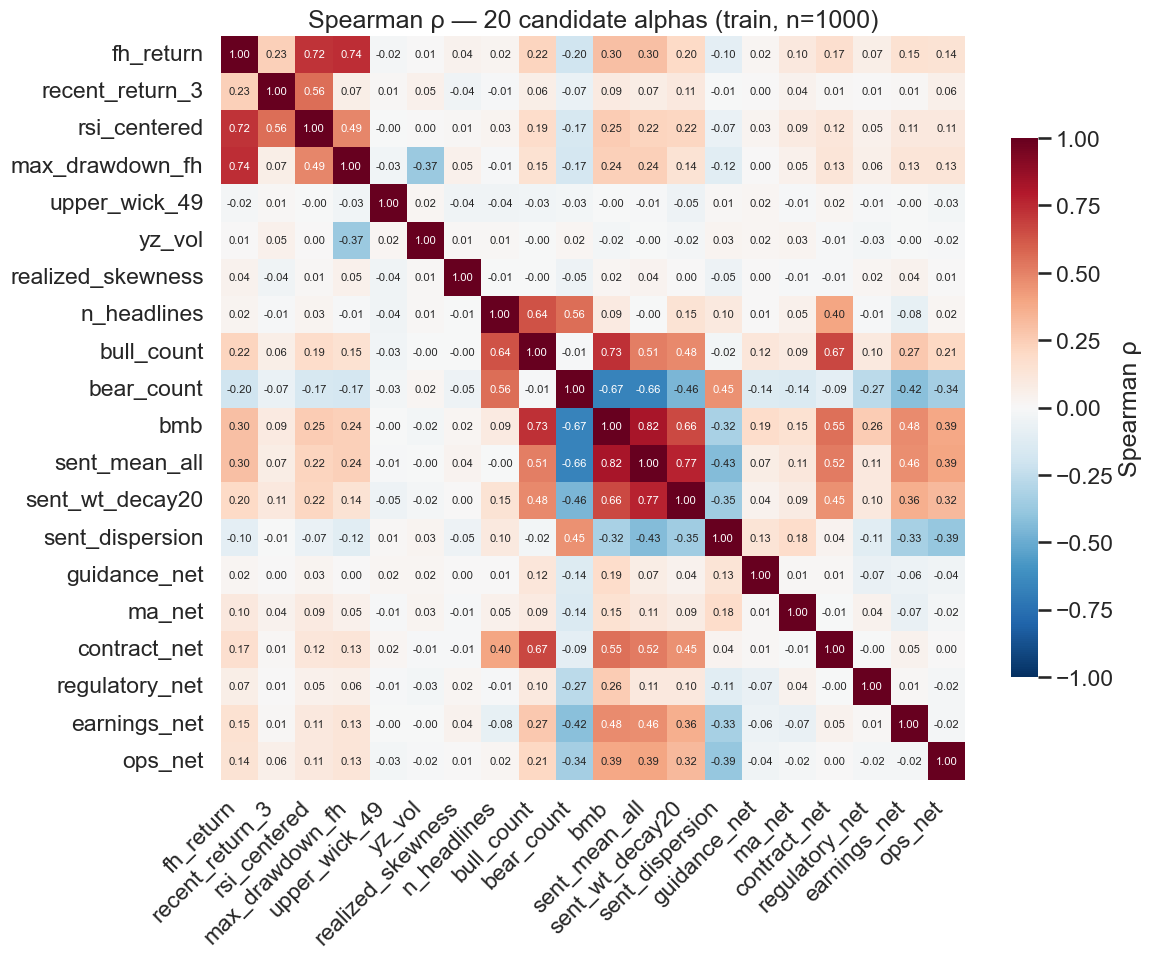

In [2]:
spearman_mat = df[ALPHA_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    spearman_mat,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"shrink": 0.7, "label": "Spearman ρ"},
    annot_kws={"size": 8},
    ax=ax,
)
ax.set_title("Spearman ρ — 20 candidate alphas (train, n=1000)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.savefig(PLOT_DIR / "alphas_01_corr.png", dpi=140, bbox_inches="tight")
plt.show()

## Section 2 — IC panel

Pearson r of each alpha with `target_return`, ranked by |r|. 95% bootstrap CI (1000 resamples) as error bars. Dashed vertical lines mark the |r| threshold corresponding to Bonferroni-adjusted p=0.05/20. An alpha is "signal-like" if its CI stays on one side of zero AND |r| exceeds the dashed line.

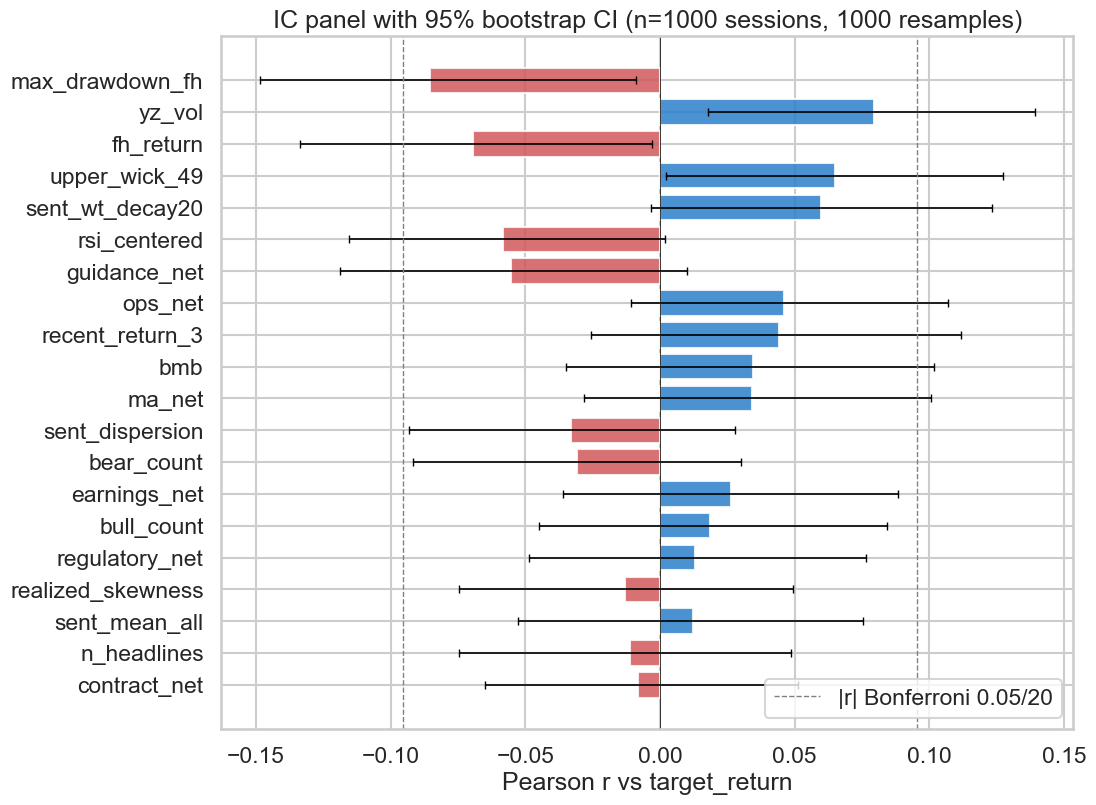


IC ranked by |r| (Bonferroni α = 0.0025; |r| threshold ≈ 0.0955):
            alpha         r        p  p_bonf_thresh  passes_bonf        lo        hi
  max_drawdown_fh -0.085495 0.006827         0.0025        False -0.148564 -0.008987
           yz_vol  0.079376 0.012042         0.0025        False  0.017958  0.139176
        fh_return -0.069436 0.028115         0.0025        False -0.133719 -0.002899
    upper_wick_49  0.064896 0.040191         0.0025        False  0.002383  0.127491
  sent_wt_decay20  0.059814 0.058650         0.0025        False -0.003314  0.123195
     rsi_centered -0.058123 0.066172         0.0025        False -0.115332  0.001767
     guidance_net -0.055398 0.079948         0.0025        False -0.118665  0.010205
          ops_net  0.046156 0.144698         0.0025        False -0.010735  0.106879
  recent_return_3  0.044139 0.163101         0.0025        False -0.025684  0.111755
              bmb  0.034441 0.276557         0.0025        False -0.034990  0.10179

In [3]:
rng = np.random.default_rng(42)
N = len(df)
n_boot = 1000
y = df["target_return"].to_numpy()

# Bonferroni-corrected |r| threshold for p = 0.05 / 20, two-sided, n=1000.
from scipy.stats import t as tdist
alpha_bonf = 0.05 / len(ALPHA_COLS)
t_crit = tdist.ppf(1 - alpha_bonf / 2, df=N - 2)
r_thresh = t_crit / np.sqrt(t_crit ** 2 + (N - 2))

records = []
for col in ALPHA_COLS:
    x = df[col].to_numpy()
    r, p = stats.pearsonr(x, y)
    # Bootstrap CI
    boots = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, N, size=N)
        xb = x[idx]
        yb = y[idx]
        sx = xb.std()
        sy = yb.std()
        if sx == 0 or sy == 0:
            boots[b] = np.nan
        else:
            boots[b] = np.corrcoef(xb, yb)[0, 1]
    lo, hi = np.nanpercentile(boots, [2.5, 97.5])
    records.append({"alpha": col, "r": r, "p": p, "lo": lo, "hi": hi})

ic = pd.DataFrame(records).sort_values("r", key=lambda s: s.abs(), ascending=True)

fig, ax = plt.subplots(figsize=(11, 9))
ypos = np.arange(len(ic))
colors = ["#2a7fc9" if r > 0 else "#d1585b" for r in ic["r"]]
ax.barh(ypos, ic["r"], color=colors, alpha=0.85)
ax.errorbar(
    ic["r"], ypos,
    xerr=[ic["r"] - ic["lo"], ic["hi"] - ic["r"]],
    fmt="none", ecolor="black", capsize=3, lw=1.2,
)
ax.axvline(0, color="k", lw=0.6)
ax.axvline(r_thresh, color="grey", ls="--", lw=1.0, label=f"|r| Bonferroni 0.05/{len(ALPHA_COLS)}")
ax.axvline(-r_thresh, color="grey", ls="--", lw=1.0)
ax.set_yticks(ypos)
ax.set_yticklabels(ic["alpha"])
ax.set_xlabel("Pearson r vs target_return")
ax.set_title("IC panel with 95% bootstrap CI (n=1000 sessions, 1000 resamples)")
ax.legend(loc="lower right")
plt.savefig(PLOT_DIR / "alphas_02_ic.png", dpi=140, bbox_inches="tight")
plt.show()

ic_table = ic.sort_values("r", key=lambda s: s.abs(), ascending=False).copy()
ic_table["p_bonf_thresh"] = alpha_bonf
ic_table["passes_bonf"] = ic_table["p"] < alpha_bonf
print("\nIC ranked by |r| (Bonferroni α = %.4g; |r| threshold ≈ %.4f):" % (alpha_bonf, r_thresh))
print(ic_table[["alpha", "r", "p", "p_bonf_thresh", "passes_bonf", "lo", "hi"]].to_string(index=False))

## Section 3 — Standalone Sharpe-vs-k curves

For each alpha, z-score it robustly (median / MAD·1.4826), then sweep k ∈ [−3, 3] and compute Sharpe of `clip(1 + k·z, 0.2, 2.0) · target_return`. Highlights the top-5 alphas whose peak-|Sharpe| most exceeds the always-long baseline (≈ 2.77). Sign of best-k reveals the intended direction of the rule.

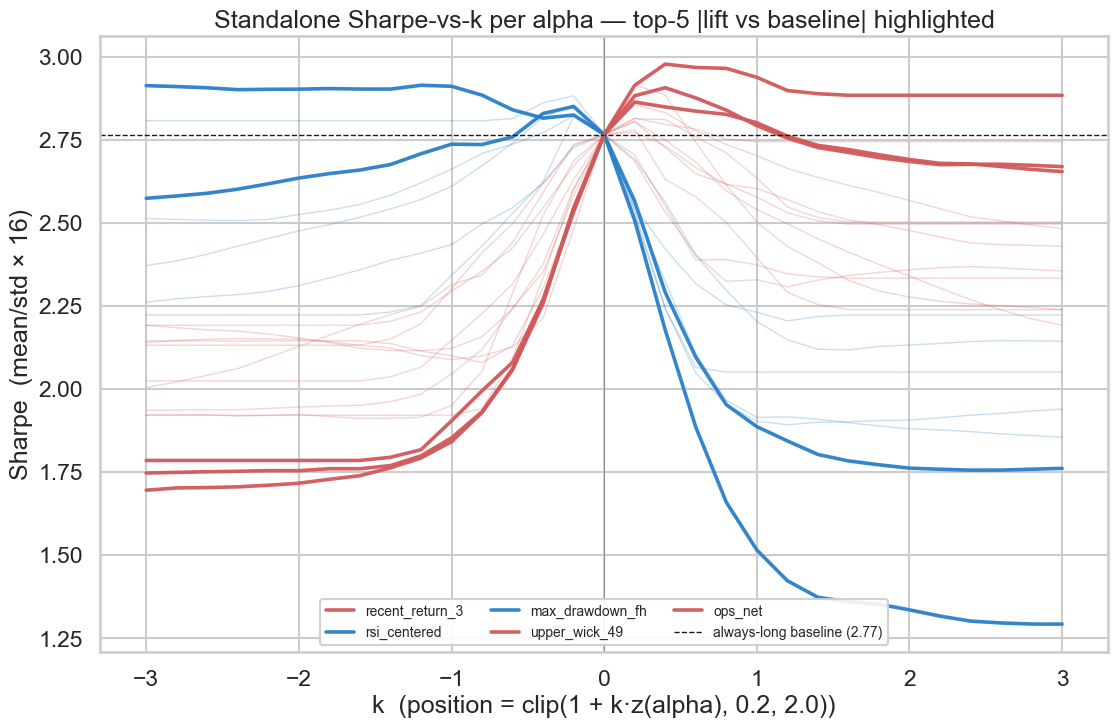


Best-k per alpha (sorted by |lift vs always-long baseline|):
            alpha  best_k  best_sharpe  lift_vs_baseline
  max_drawdown_fh  +3.000       +1.293            -1.473
    upper_wick_49  -3.000       +1.696            -1.070
  recent_return_3  -3.000       +1.747            -1.019
     rsi_centered  +2.400       +1.756            -1.010
          ops_net  -3.000       +1.785            -0.981
  sent_dispersion  +3.000       +1.855            -0.911
        fh_return  +1.200       +1.893            -0.873
           yz_vol  -1.600       +1.912            -0.854
           ma_net  -3.000       +1.921            -0.845
              bmb  -3.000       +1.936            -0.830
      n_headlines  -3.000       +2.005            -0.761
     earnings_net  -3.000       +2.025            -0.741
     guidance_net  +0.800       +2.051            -0.715
       bull_count  -0.800       +2.080            -0.686
  sent_wt_decay20  -1.000       +2.089            -0.677
    sent_mean_all  -1.200 

In [4]:
def robust_z(x: np.ndarray) -> np.ndarray:
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    scale = mad * 1.4826
    if scale == 0:
        sd = x.std()
        scale = sd if sd > 0 else 1.0
    return (x - med) / scale

def sharpe_at_k(z: np.ndarray, y: np.ndarray, k: float) -> float:
    pos = np.clip(1.0 + k * z, 0.2, 2.0)
    pnl = pos * y
    sd = pnl.std()
    if sd == 0:
        return 0.0
    return pnl.mean() / sd * 16.0

K_GRID = np.linspace(-3, 3, 31)
baseline_sharpe = y.mean() / y.std() * 16.0  # always-long k=0

sharpe_curves = {}
best_rows = []
for col in ALPHA_COLS:
    z = robust_z(df[col].to_numpy())
    curve = np.array([sharpe_at_k(z, y, k) for k in K_GRID])
    sharpe_curves[col] = curve
    i_best = int(np.argmax(np.abs(curve - baseline_sharpe)))
    best_rows.append({
        "alpha": col,
        "best_k": K_GRID[i_best],
        "best_sharpe": curve[i_best],
        "lift_vs_baseline": curve[i_best] - baseline_sharpe,
    })

best_df = pd.DataFrame(best_rows).sort_values("lift_vs_baseline", key=lambda s: s.abs(), ascending=False)
top5 = set(best_df.head(5)["alpha"].tolist())

fig, ax = plt.subplots(figsize=(13, 8))
for col in ALPHA_COLS:
    curve = sharpe_curves[col]
    i_best = int(np.argmax(np.abs(curve - baseline_sharpe)))
    sign = np.sign(K_GRID[i_best]) if K_GRID[i_best] != 0 else 1
    base_color = "#2a7fc9" if sign >= 0 else "#d1585b"
    if col in top5:
        ax.plot(K_GRID, curve, lw=2.6, label=col, color=base_color, alpha=0.95)
    else:
        ax.plot(K_GRID, curve, lw=1.0, color=base_color, alpha=0.25)

ax.axhline(baseline_sharpe, color="k", ls="--", lw=1.0, label=f"always-long baseline ({baseline_sharpe:.2f})")
ax.axvline(0, color="grey", lw=0.6)
ax.set_xlabel("k  (position = clip(1 + k·z(alpha), 0.2, 2.0))")
ax.set_ylabel("Sharpe  (mean/std × 16)")
ax.set_title("Standalone Sharpe-vs-k per alpha — top-5 |lift vs baseline| highlighted")
ax.legend(loc="lower center", ncol=3, fontsize=10, framealpha=0.9)
plt.savefig(PLOT_DIR / "alphas_03_sharpe_vs_k.png", dpi=140, bbox_inches="tight")
plt.show()

print("\nBest-k per alpha (sorted by |lift vs always-long baseline|):")
print(best_df.to_string(index=False, float_format=lambda v: f"{v:+.3f}"))

## Section 4 — Decile monotonicity grid

4×5 grid — one panel per alpha. Mean `target_return` per decile with 95% CI error bars. The per-panel title flags whether the (decile rank, mean return) relationship is monotone (Spearman ρ > 0.6 in absolute value). Use this to distinguish linear alphas (monotone) from fade/tail rules (U-shape).

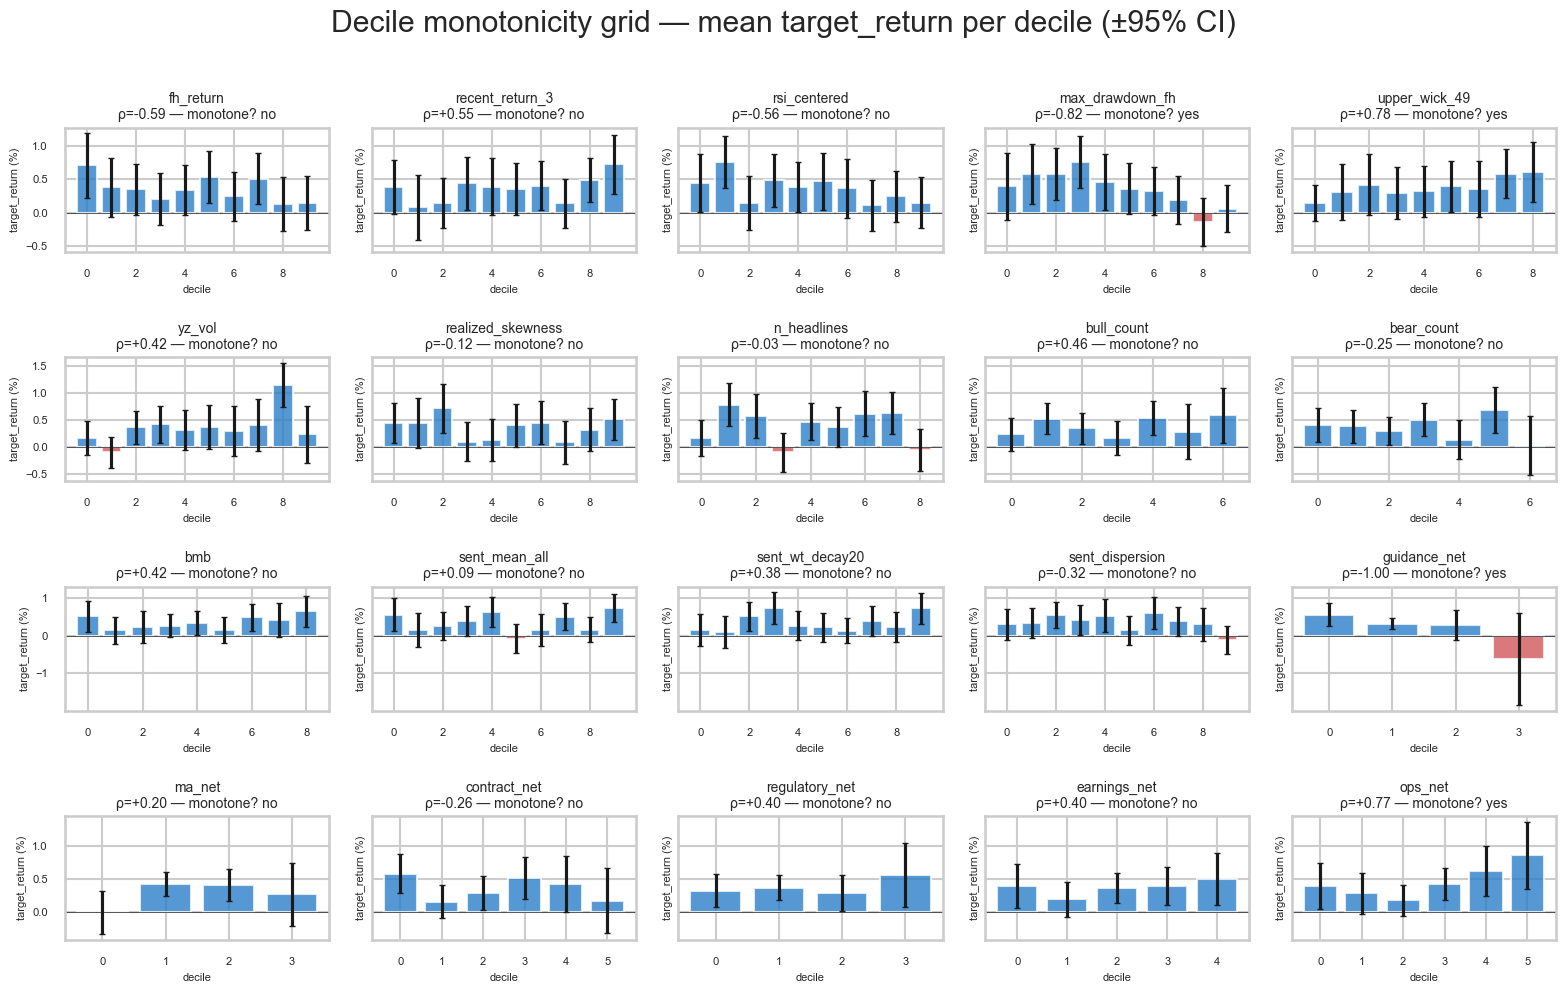

In [5]:
fig, axes = plt.subplots(4, 5, figsize=(16, 10), sharey="row")
axes = axes.ravel()

for ax, col in zip(axes, ALPHA_COLS):
    try:
        q = pd.qcut(df[col], 10, duplicates="drop", labels=False)
    except ValueError:
        q = pd.Series(np.zeros(len(df), dtype=int), index=df.index)
    g = pd.DataFrame({"q": q.to_numpy(), "y": y})
    agg = g.groupby("q")["y"].agg(["mean", "std", "count"]).reset_index()
    ci = 1.96 * agg["std"] / np.sqrt(agg["count"].clip(lower=1))
    rho = np.nan
    if len(agg) >= 3:
        rho, _ = stats.spearmanr(agg["q"], agg["mean"])
    mono = (abs(rho) > 0.6) if not np.isnan(rho) else False
    bar_colors = ["#2a7fc9" if v >= 0 else "#d1585b" for v in agg["mean"]]
    ax.bar(agg["q"], agg["mean"] * 100, yerr=ci.to_numpy() * 100, color=bar_colors, alpha=0.8, capsize=2)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{col}\nρ={rho:+.2f} — monotone? {'yes' if mono else 'no'}", fontsize=10)
    ax.set_xlabel("decile", fontsize=8)
    ax.set_ylabel("target_return (%)", fontsize=8)
    ax.tick_params(axis="both", labelsize=8)

# Hide any spare axes if ALPHA_COLS < 20.
for j in range(len(ALPHA_COLS), len(axes)):
    axes[j].axis("off")

fig.suptitle("Decile monotonicity grid — mean target_return per decile (±95% CI)", y=1.00)
fig.tight_layout()
plt.savefig(PLOT_DIR / "alphas_04_deciles.png", dpi=140, bbox_inches="tight")
plt.show()

## Section 5 — IC stability across 5 folds

Per-alpha Pearson r computed independently on each of 5 random folds (KFold, shuffle=True, seed=42). The median line collapses to the full-sample IC; min/max whiskers expose alphas whose IC flips sign depending on the fold — those should be viewed sceptically even if the overall IC is significant.

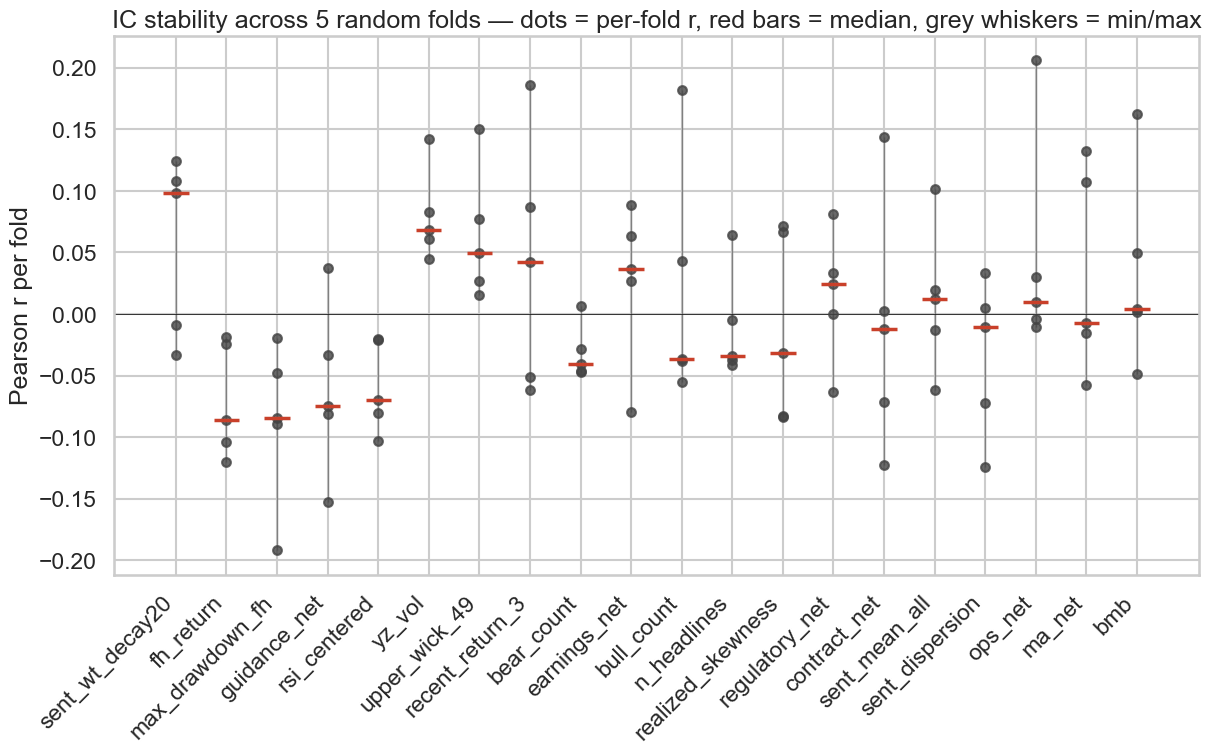

In [6]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
idx_array = np.arange(len(df))
folds = list(kf.split(idx_array))

stab_records = []
for col in ALPHA_COLS:
    x = df[col].to_numpy()
    rs = []
    for _, test_idx in folds:
        xf = x[test_idx]
        yf = y[test_idx]
        if xf.std() == 0 or yf.std() == 0:
            rs.append(np.nan)
        else:
            rs.append(np.corrcoef(xf, yf)[0, 1])
    stab_records.append({"alpha": col, "fold_rs": rs, "median": np.nanmedian(rs)})

stab = pd.DataFrame(stab_records).sort_values("median", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 7))
xpos = np.arange(len(stab))
for i, row in stab.iterrows():
    rs = row["fold_rs"]
    ax.scatter([i] * len(rs), rs, color="#444444", alpha=0.8, s=40, zorder=3)
    ax.vlines(i, np.nanmin(rs), np.nanmax(rs), color="grey", lw=1.0, zorder=2)
    ax.hlines(row["median"], i - 0.25, i + 0.25, color="#c9402a", lw=2.5, zorder=4)

ax.axhline(0, color="k", lw=0.6)
ax.set_xticks(xpos)
ax.set_xticklabels(stab["alpha"], rotation=45, ha="right")
ax.set_ylabel("Pearson r per fold")
ax.set_title("IC stability across 5 random folds — dots = per-fold r, red bars = median, grey whiskers = min/max")
plt.savefig(PLOT_DIR / "alphas_05_stability.png", dpi=140, bbox_inches="tight")
plt.show()

## Section 6 — Top-30 templates × target_return

For each of the top-30 skeletons, compute mean `target_return` across sessions where the template appears ≥1 time, with 95% bootstrap CI. Reference line = global mean target_return (+0.35%). Skeletons whose CI sits clearly on one side of the global mean are candidate standalone template rules.

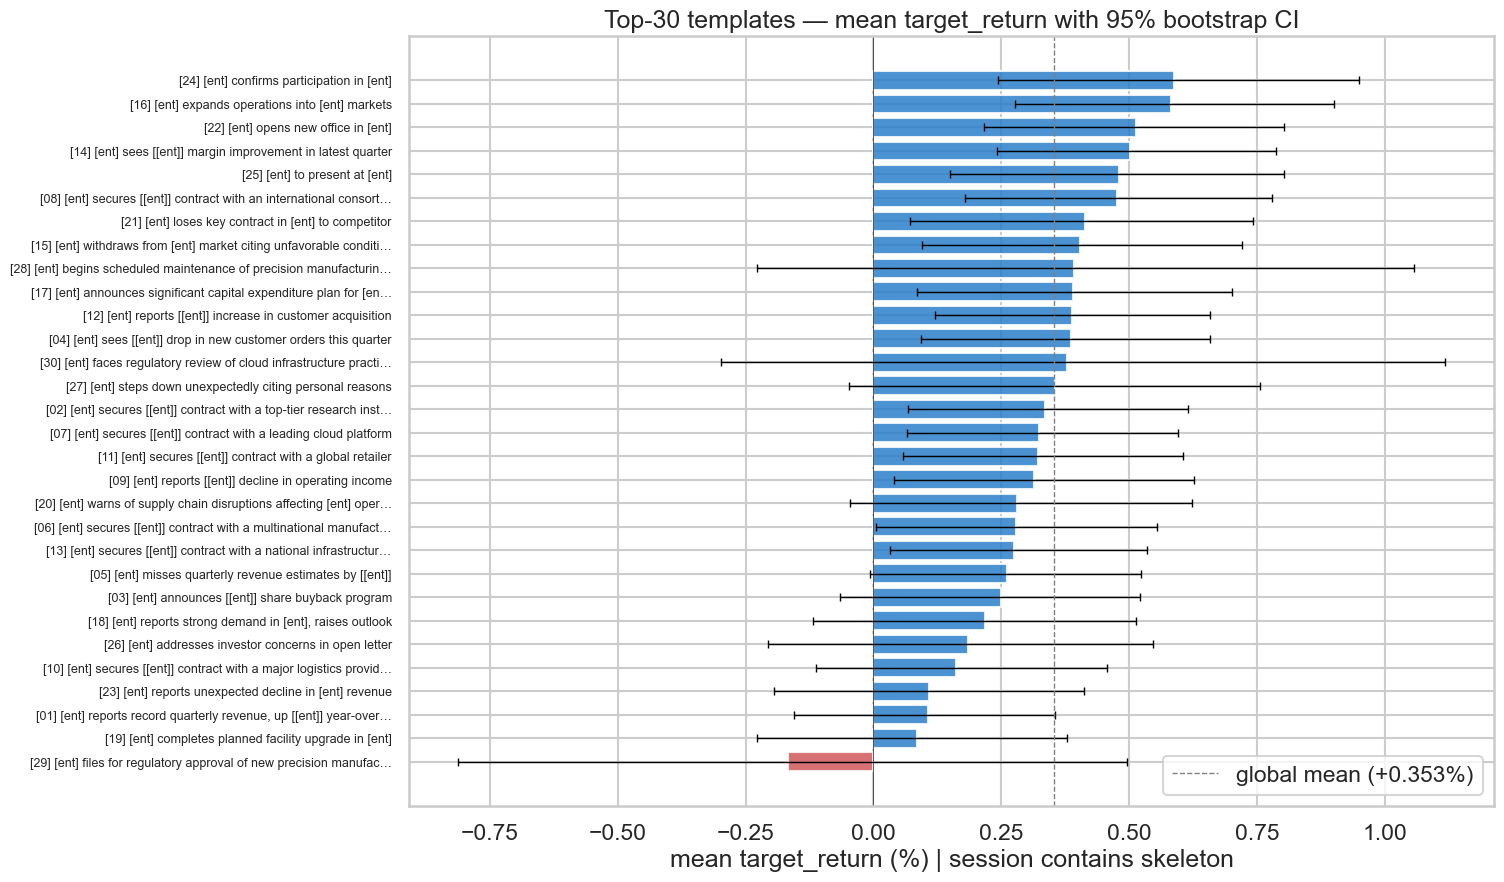

In [7]:
rng6 = np.random.default_rng(7)
n_boot = 1000
global_mean = targets["target_return"].mean()

tpl_rows = []
for _, r in tpl_dict.iterrows():
    rank = int(r["rank"])
    col = f"tpl_{rank}"
    if col not in df_tpl.columns:
        continue
    mask = df_tpl[col] > 0
    n_sess = int(mask.sum())
    if n_sess < 2:
        continue
    y_sub = df_tpl.loc[mask, "target_return"].to_numpy()
    boots = np.array([y_sub[rng6.integers(0, n_sess, size=n_sess)].mean() for _ in range(n_boot)])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    skel_trim = r["skeleton"][:60] + ("…" if len(r["skeleton"]) > 60 else "")
    tpl_rows.append({
        "rank": rank,
        "col": col,
        "skeleton": r["skeleton"],
        "skeleton_short": f"[{rank:02d}] {skel_trim}",
        "n_sessions": n_sess,
        "mean_y": y_sub.mean(),
        "lo": lo,
        "hi": hi,
    })
tpl_r = pd.DataFrame(tpl_rows).sort_values("mean_y")

fig, ax = plt.subplots(figsize=(14, 10))
ypos = np.arange(len(tpl_r))
colors = ["#2a7fc9" if m >= 0 else "#d1585b" for m in tpl_r["mean_y"]]
ax.barh(ypos, tpl_r["mean_y"] * 100, color=colors, alpha=0.85)
ax.errorbar(
    tpl_r["mean_y"] * 100, ypos,
    xerr=[(tpl_r["mean_y"] - tpl_r["lo"]) * 100, (tpl_r["hi"] - tpl_r["mean_y"]) * 100],
    fmt="none", ecolor="black", capsize=3, lw=1.0,
)
ax.axvline(0, color="k", lw=0.5)
ax.axvline(global_mean * 100, color="grey", ls="--", lw=1.0, label=f"global mean ({global_mean:+.3%})")
ax.set_yticks(ypos)
ax.set_yticklabels(tpl_r["skeleton_short"], fontsize=9)
ax.set_xlabel("mean target_return (%) | session contains skeleton")
ax.set_title("Top-30 templates — mean target_return with 95% bootstrap CI")
ax.legend(loc="lower right")
plt.savefig(PLOT_DIR / "alphas_06_template_returns.png", dpi=140, bbox_inches="tight")
plt.show()

## Section 7 — Template frequency curve

Log-log rank vs total_count plus cumulative-coverage overlay. The rank at which cumulative coverage crosses 80% tells us whether top-30 captures the bulk of headline mass or whether we are leaving signal on the table in the long tail.

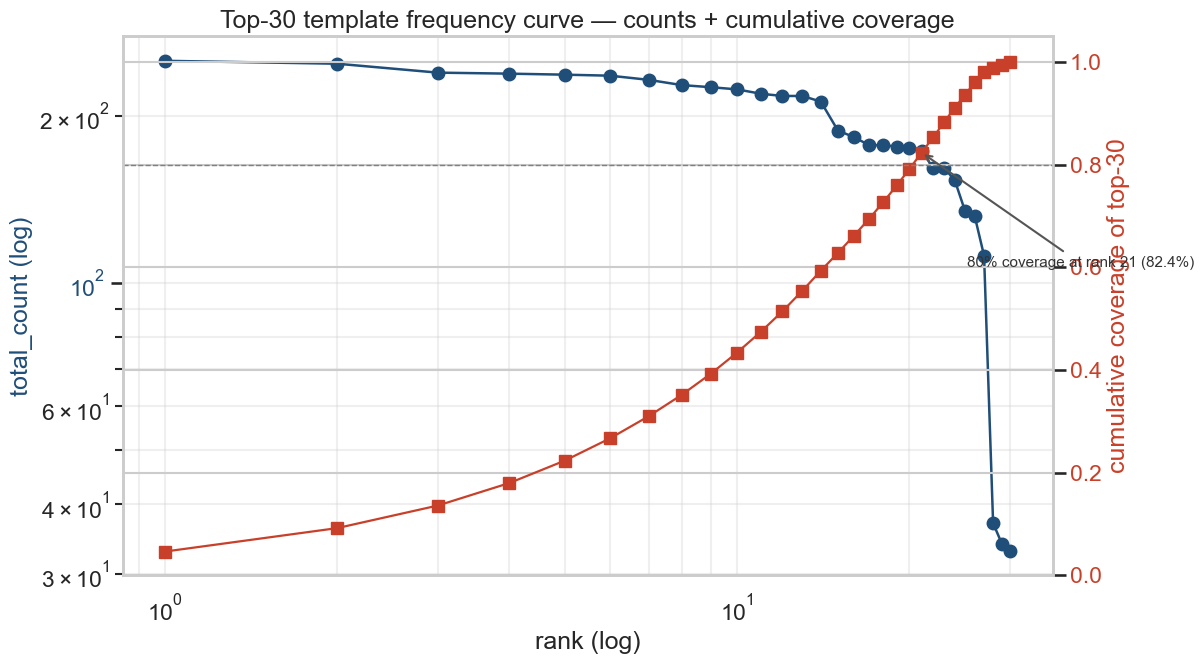

In [8]:
tpl_sorted = tpl_dict.sort_values("rank").copy()
counts = tpl_sorted["total_count"].to_numpy().astype(float)
ranks = tpl_sorted["rank"].to_numpy().astype(int)
cum_cov = counts.cumsum() / counts.sum()

fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.loglog(ranks, counts, marker="o", color="#1f4e79", lw=1.8, label="count per skeleton")
ax1.set_xlabel("rank (log)")
ax1.set_ylabel("total_count (log)", color="#1f4e79")
ax1.tick_params(axis="y", labelcolor="#1f4e79")
ax1.grid(True, which="both", alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(ranks, cum_cov, marker="s", color="#c9402a", lw=1.6, label="cumulative coverage")
ax2.set_ylabel("cumulative coverage of top-30", color="#c9402a")
ax2.tick_params(axis="y", labelcolor="#c9402a")
ax2.axhline(0.8, color="grey", ls="--", lw=1.0)
ax2.set_ylim(0, 1.05)

idx80 = int(np.searchsorted(cum_cov, 0.8))
if idx80 < len(ranks):
    r80 = ranks[idx80]
    c80 = cum_cov[idx80]
    ax2.annotate(
        f"80% coverage at rank {r80} ({c80:.1%})",
        xy=(r80, c80), xytext=(r80 * 1.2, 0.6),
        fontsize=11, color="#333333",
        arrowprops=dict(arrowstyle="->", color="#555"),
    )

ax1.set_title("Top-30 template frequency curve — counts + cumulative coverage")
plt.savefig(PLOT_DIR / "alphas_07_template_freq.png", dpi=140, bbox_inches="tight")
plt.show()

## Section 8 — BMB coverage gap

For each top-30 skeleton, test whether it matches `_BULL_RE` or `_BEAR_RE`. Segments coloured bull / bear / neither. High-frequency skeletons in "neither" are strong candidates to add to the BMB vocabulary.

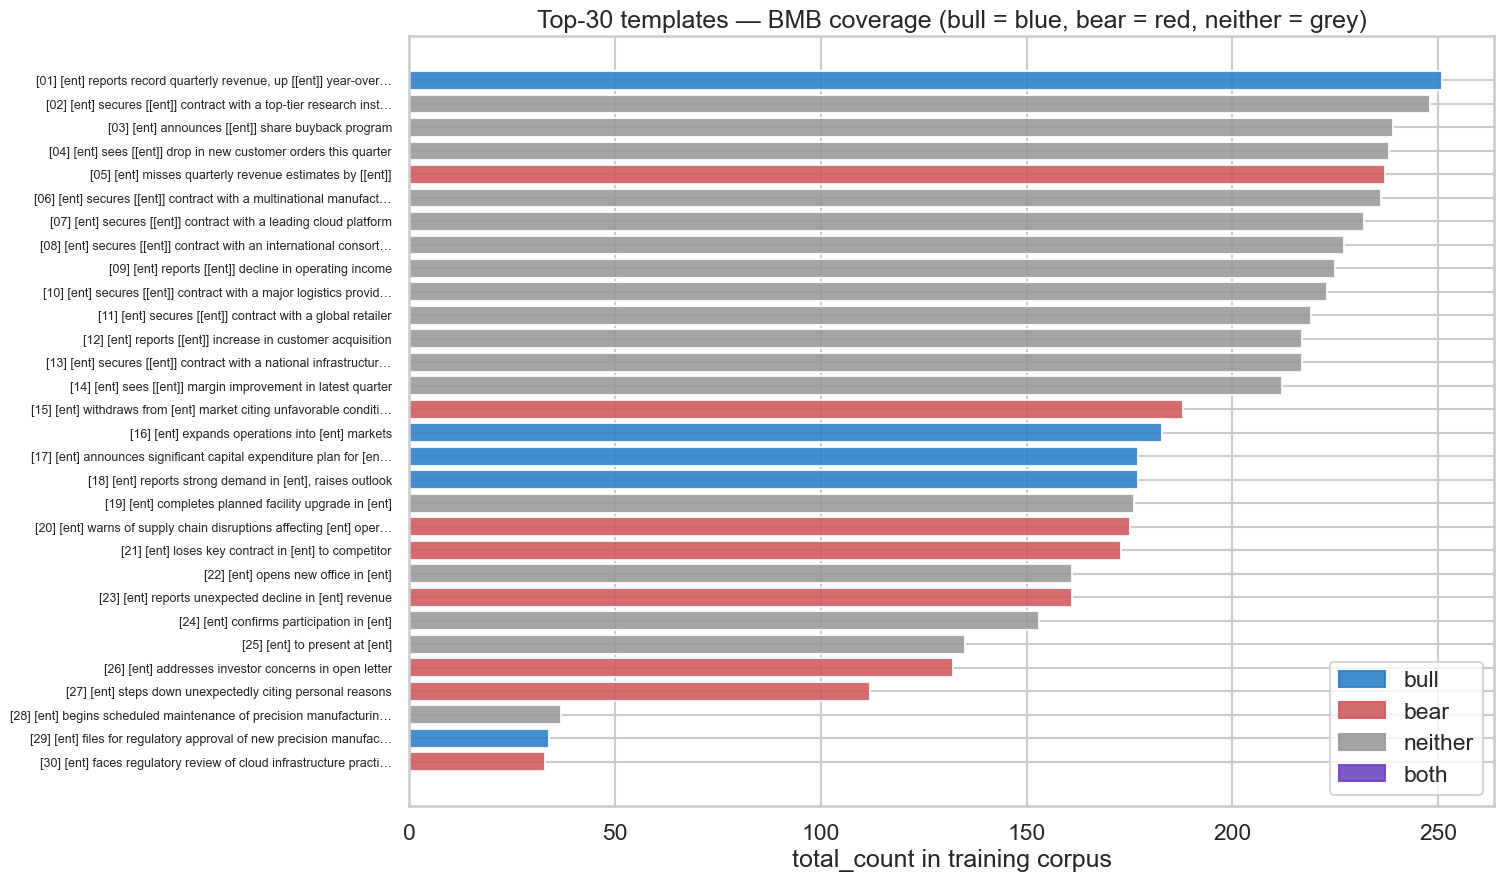


BMB coverage summary (top-30):
class
neither    17
bear        8
bull        5
headline mass in 'neither' class: 3395 / 5428 (62.5%)

High-count 'neither' skeletons (top gaps):
 rank  total_count                                                          skeleton
    2          248 [ent] secures [[ent]] contract with a top-tier research institute
    3          239                     [ent] announces [[ent]] share buyback program
    4          238       [ent] sees [[ent]] drop in new customer orders this quarter
    6          236  [ent] secures [[ent]] contract with a multinational manufacturer
    7          232      [ent] secures [[ent]] contract with a leading cloud platform
    8          227   [ent] secures [[ent]] contract with an international consortium
    9          225                 [ent] reports [[ent]] decline in operating income
   10          223    [ent] secures [[ent]] contract with a major logistics provider
   11          219             [ent] secures [[ent]] cont

In [9]:
from src.features import _BULL_RE, _BEAR_RE  # noqa: E402

def classify(skel: str) -> str:
    is_bull = bool(_BULL_RE.search(skel))
    is_bear = bool(_BEAR_RE.search(skel))
    if is_bull and is_bear:
        return "both"
    if is_bull:
        return "bull"
    if is_bear:
        return "bear"
    return "neither"

tpl_cls = tpl_dict.sort_values("rank").copy()
tpl_cls["class"] = tpl_cls["skeleton"].map(classify)
tpl_cls["skeleton_short"] = tpl_cls.apply(
    lambda r: f"[{int(r['rank']):02d}] " + (r["skeleton"][:60] + ("…" if len(r["skeleton"]) > 60 else "")),
    axis=1,
)

palette = {"bull": "#2a7fc9", "bear": "#d1585b", "neither": "#999999", "both": "#6f42c1"}
# Sort by rank descending so rank 1 is at top of horizontal bar chart.
tpl_cls_plot = tpl_cls.sort_values("rank", ascending=False)
ypos = np.arange(len(tpl_cls_plot))
bar_colors = [palette[c] for c in tpl_cls_plot["class"]]

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(ypos, tpl_cls_plot["total_count"], color=bar_colors, alpha=0.88)
ax.set_yticks(ypos)
ax.set_yticklabels(tpl_cls_plot["skeleton_short"], fontsize=9)
ax.set_xlabel("total_count in training corpus")
ax.set_title("Top-30 templates — BMB coverage (bull = blue, bear = red, neither = grey)")
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.88) for c in palette.values()]
ax.legend(legend_handles, list(palette.keys()), loc="lower right")
plt.savefig(PLOT_DIR / "alphas_08_bmb_gap.png", dpi=140, bbox_inches="tight")
plt.show()

print("\nBMB coverage summary (top-30):")
print(tpl_cls["class"].value_counts().to_string())
miss_mass = tpl_cls.loc[tpl_cls["class"] == "neither", "total_count"].sum()
total_mass = tpl_cls["total_count"].sum()
print(f"headline mass in 'neither' class: {miss_mass} / {total_mass} ({miss_mass / total_mass:.1%})")
print("\nHigh-count 'neither' skeletons (top gaps):")
print(
    tpl_cls.loc[tpl_cls["class"] == "neither"]
    .sort_values("total_count", ascending=False)
    .head(10)[["rank", "total_count", "skeleton"]]
    .to_string(index=False)
)

## Section 9 — Per-template Sharpe contribution

Naive standalone rule: "go long 1.0 unit when the session contains template T, 0 otherwise." Computes Sharpe of the resulting PnL with 95% bootstrap CI. Dashed line = always-long baseline. Bars above the baseline are templates where conditional-long improves Sharpe by itself; below = templates whose presence correlates with worse outcomes.

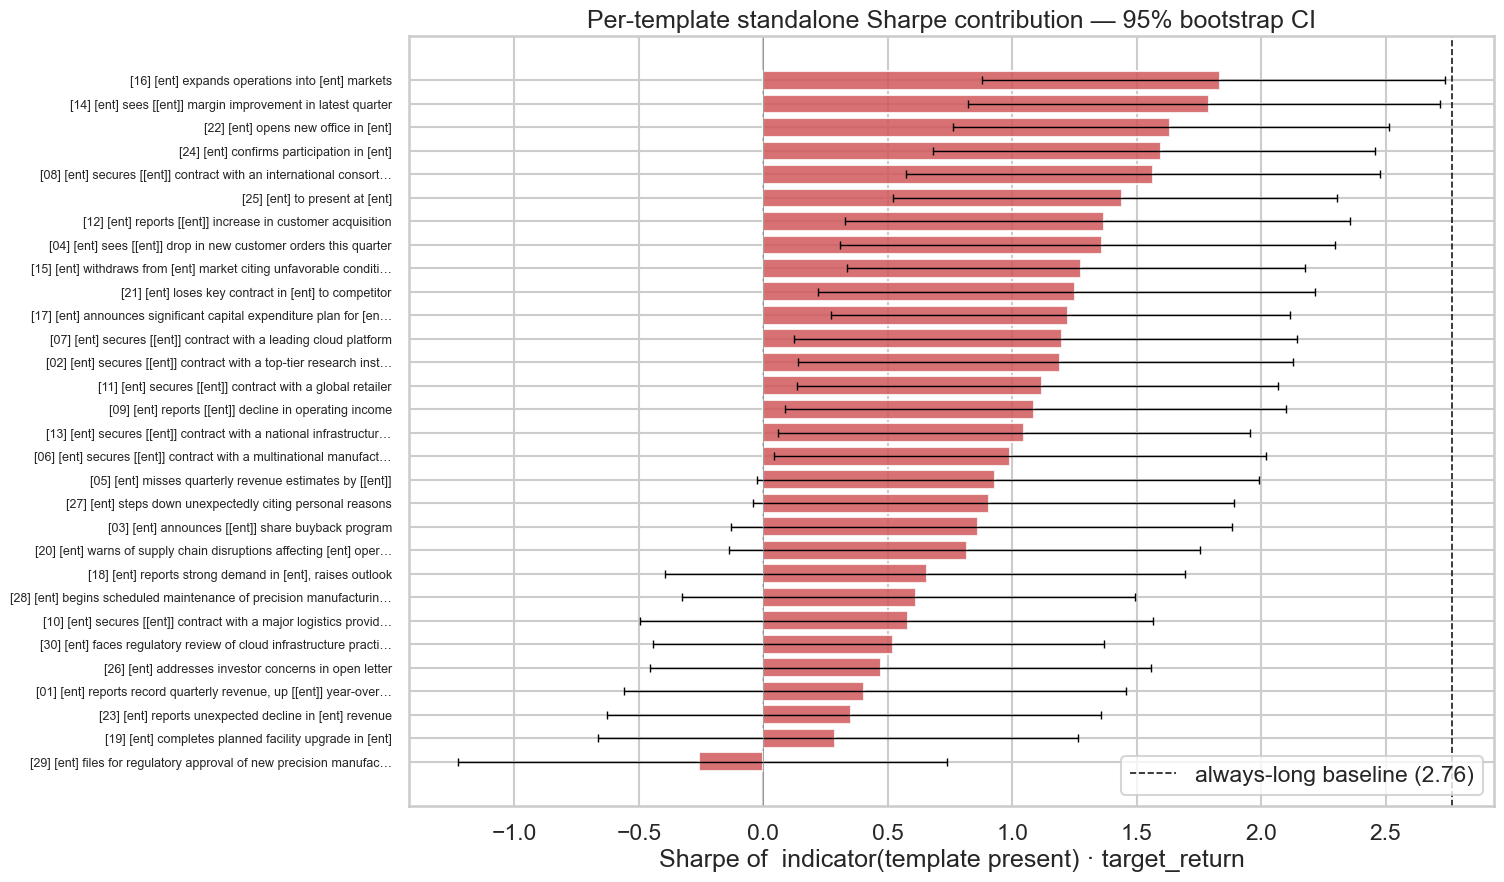


Top-5 templates by standalone Sharpe:
 rank  n_hit  sharpe     lo     hi                                                        skeleton
   16    165  +1.833 +0.878 +2.738                     [ent] expands operations into [ent] markets
   14    191  +1.792 +0.823 +2.719         [ent] sees [[ent]] margin improvement in latest quarter
   22    149  +1.633 +0.762 +2.512                                 [ent] opens new office in [ent]
   24    136  +1.596 +0.684 +2.456                           [ent] confirms participation in [ent]
    8    194  +1.565 +0.572 +2.477 [ent] secures [[ent]] contract with an international consortium

Bottom-5 templates by standalone Sharpe:
 rank  n_hit  sharpe     lo     hi                                                                    skeleton
   29     33  -0.257 -1.225 +0.739 [ent] files for regulatory approval of new precision manufacturing offering
   19    158  +0.287 -0.663 +1.265                           [ent] completes planned facility upgrade i

In [10]:
rng9 = np.random.default_rng(123)
n_boot = 1000
baseline = targets["target_return"].mean() / targets["target_return"].std() * 16.0
y_all = df_tpl["target_return"].to_numpy()
N9 = len(df_tpl)

def sharpe_of(pnl: np.ndarray) -> float:
    sd = pnl.std()
    if sd == 0:
        return 0.0
    return pnl.mean() / sd * 16.0

tpl_sh = []
for _, r in tpl_dict.iterrows():
    rank = int(r["rank"])
    col = f"tpl_{rank}"
    if col not in df_tpl.columns:
        continue
    ind = (df_tpl[col] > 0).astype(float).to_numpy()
    pnl = ind * y_all
    sh = sharpe_of(pnl)
    boots = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng9.integers(0, N9, size=N9)
        boots[b] = sharpe_of(ind[idx] * y_all[idx])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    skel_trim = r["skeleton"][:60] + ("…" if len(r["skeleton"]) > 60 else "")
    tpl_sh.append({
        "rank": rank,
        "col": col,
        "skeleton": r["skeleton"],
        "skeleton_short": f"[{rank:02d}] {skel_trim}",
        "n_hit": int(ind.sum()),
        "sharpe": sh,
        "lo": lo,
        "hi": hi,
    })

tsh = pd.DataFrame(tpl_sh).sort_values("sharpe")

fig, ax = plt.subplots(figsize=(14, 10))
ypos = np.arange(len(tsh))
bar_colors = ["#2a7fc9" if s >= baseline else "#d1585b" for s in tsh["sharpe"]]
ax.barh(ypos, tsh["sharpe"], color=bar_colors, alpha=0.85)
ax.errorbar(
    tsh["sharpe"], ypos,
    xerr=[tsh["sharpe"] - tsh["lo"], tsh["hi"] - tsh["sharpe"]],
    fmt="none", ecolor="black", capsize=3, lw=1.0,
)
ax.axvline(baseline, color="k", ls="--", lw=1.2, label=f"always-long baseline ({baseline:.2f})")
ax.axvline(0, color="grey", lw=0.5)
ax.set_yticks(ypos)
ax.set_yticklabels(tsh["skeleton_short"], fontsize=9)
ax.set_xlabel("Sharpe of  indicator(template present) · target_return")
ax.set_title("Per-template standalone Sharpe contribution — 95% bootstrap CI")
ax.legend(loc="lower right")
plt.savefig(PLOT_DIR / "alphas_09_template_sharpe.png", dpi=140, bbox_inches="tight")
plt.show()

print("\nTop-5 templates by standalone Sharpe:")
print(
    tsh.sort_values("sharpe", ascending=False)
    .head(5)[["rank", "n_hit", "sharpe", "lo", "hi", "skeleton"]]
    .to_string(index=False, float_format=lambda v: f"{v:+.3f}")
)
print("\nBottom-5 templates by standalone Sharpe:")
print(
    tsh.sort_values("sharpe", ascending=True)
    .head(5)[["rank", "n_hit", "sharpe", "lo", "hi", "skeleton"]]
    .to_string(index=False, float_format=lambda v: f"{v:+.3f}")
)